<a href="https://colab.research.google.com/github/hamza99dahchour/NLP/blob/main/Hamza_DAHCHOUR_lab3_Part1_TextVisualization_Classical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
!pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

ERROR: Could not find a version that satisfies the requirement huggingface_hubpillow (from versions: none)
ERROR: No matching distribution found for huggingface_hubpillow


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [6]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/" + splits["train"], lines=True
)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [7]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [8]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["sci.space", "rec.sport.hockey", "talk.politics.guns"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.hockey', 'talk.politics.guns']
Filtered dataset size: 1739

Distribution:
label_text
rec.sport.hockey      600
sci.space             593
talk.politics.guns    546
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I chose these three categories because they represent completely different domains, which makes the analysis more interesting and the vocabulary differences more visible. Science, sports, and politics are three worlds that rarely overlap, so I expect the words found in each category to be highly specific and distinctive: sci.space should be dominated by technical terms like "orbit", "NASA", "satellite" or "shuttle", rec.sport.hockey by game-related words like "team", "goal", "player" or "season", and talk.politics.guns by political and legal vocabulary like "law", "rights", "government" or "weapon". I find this combination particularly interesting because it creates a strong contrast that will make it easy to observe how text representation methods like Bag of Words and TF-IDF behave differently across very distinct topics, and it will be a good test to see whether document similarity measures correctly separate these three unrelated domains.

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [9]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower() # YOUR CODE HERE
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text) # YOUR CODE HERE
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text) # YOUR CODE HERE
    # Remove numbers
    text = re.sub(r'\d+', '', text) # YOUR CODE HERE
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)) # YOUR CODE HERE
    # Remove extra whitespace
    text = ' '.join(text.split()) # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [13]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = preprocess_text(text)

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 6: Join back to string
    tokens = ' '.join(tokens)

    return tokens  # Replace with your result

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [14]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
article tom baker understanding expected error basically known bug warning system software thing checked dont right value yet arent set till launch suchlike rather fix code possibly introduce new bug tell crew see warning liftoff ignore


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

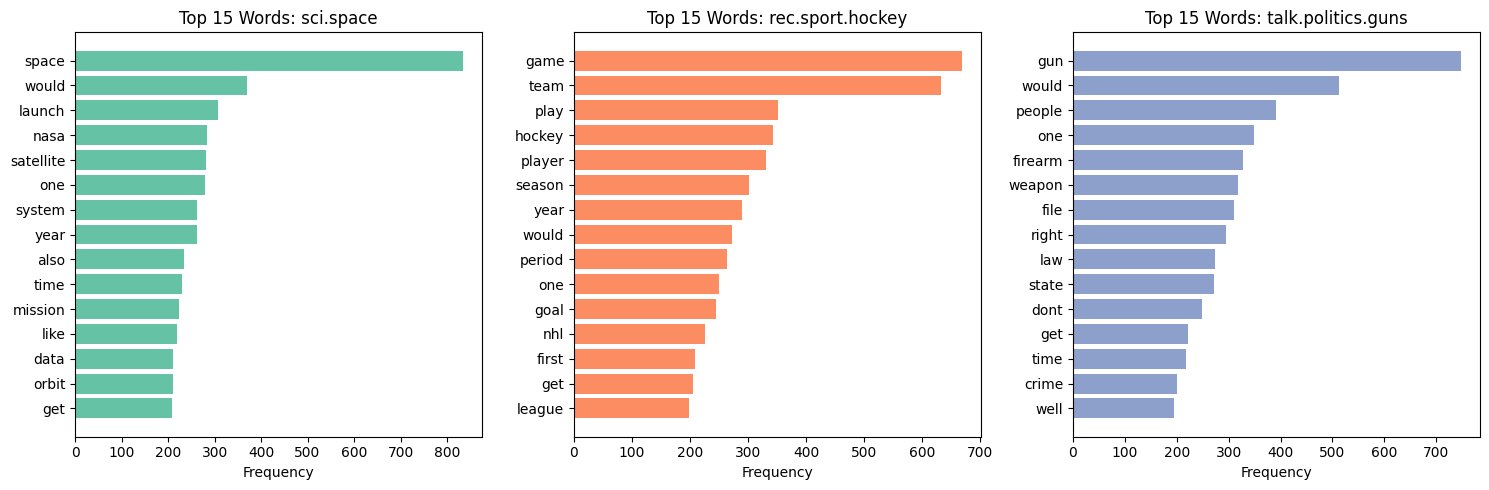

In [15]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (sci.space):*
- Unique words: "space","nasa", "satellite", "orbit", "launch", "mission"

*Category 2 (rec.sport.hockey):*
- Unique words: "hockey", "nhl", "period", "goal", "league", "player", "season"

*Category 3 (talk.politics.guns):*
- Unique words: "gun", "firearm", "weapon", "law", "crime", "right", "state"

*Shared words and explanation:*
The words "would", "one", "get", "year", "time" appear across all 3 categories. This is expected because even after removing standard stopwords, these words remain very common in English text regardless of the topic. They are general-purpose words used in any written discussion and do not carry category-specific meaning.

*Topic guessing analysis:*
Yes, the topic of each category is very easy to guess just from the top words. Seeing "nasa", "orbit", "satellite" and "space" immediately points to space science. Seeing "hockey", "nhl", "game", "team" and "goal" unambiguously identifies a sports discussion about hockey specifically. Seeing "gun", "firearm", "weapon", "law" and "crime" clearly points to a political debate around gun control. The three categories are distinct enough that even a non-expert could correctly label them from the top 15 words alone.

### C.2 Word Clouds

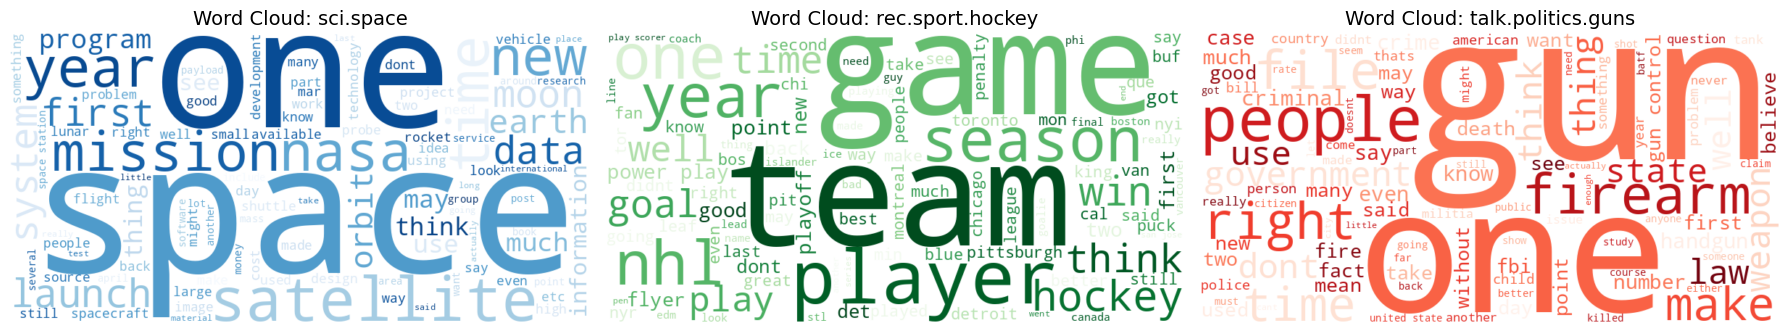

In [16]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

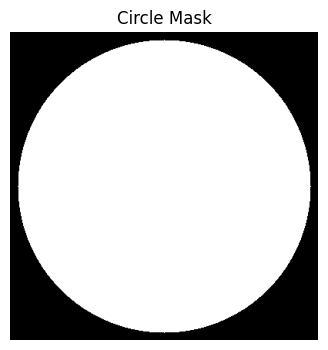

In [17]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

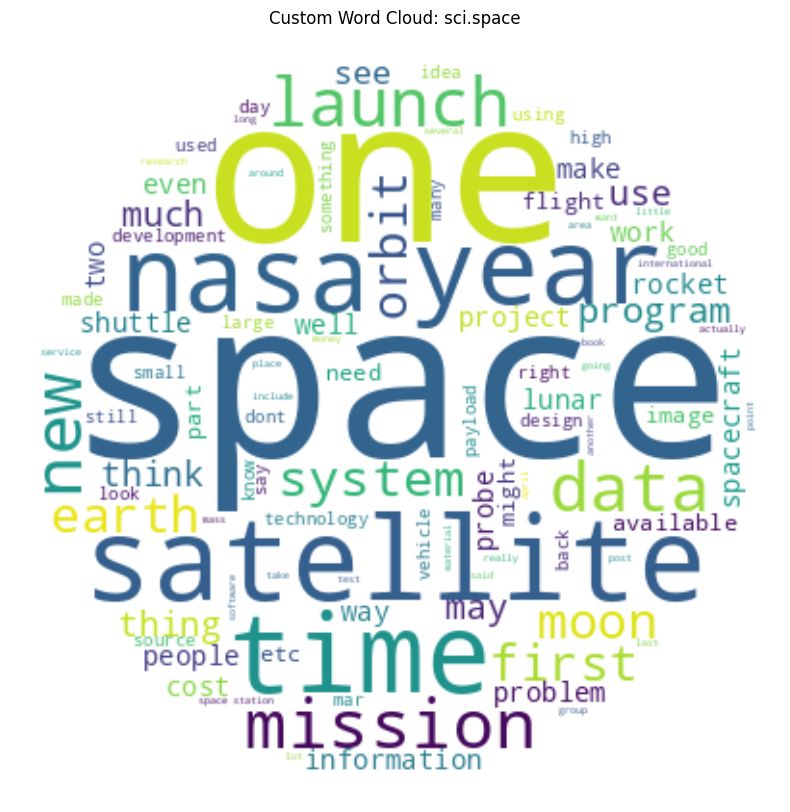

In [20]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = my_categories[0]  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

circle_mask_inverted = 255 - circle_mask

# YOUR CODE HERE
wordcloud_masked = WordCloud(
    width=400,
    height=400,
    background_color='white',
    mask=circle_mask_inverted,
    colormap='viridis',
    max_words=100
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear') # YOUR CODE HERE - display the wordcloud
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [21]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [22]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    # Add your parameters
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1739, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'access' 'accident' 'according' 'acquired' 'act' 'action'
 'activity' 'actually' 'adam' 'add' 'addition' 'address' 'advantage'
 'aerospace' 'age' 'agency' 'agent' 'ago']


### Exercise D.2: Document Similarity with BoW

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)  # YOUR CODE HERE

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1739, 1739)


In [24]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE
sim_copy = similarity_matrix.copy()
np.fill_diagonal(sim_copy, 0)

idx_flat = np.argmax(sim_copy)
idx1, idx2 = np.unravel_index(idx_flat, sim_copy.shape)

# Find indices of most similar pair
most_similar_idx = (idx1, idx2)  # (idx1, idx2)
most_similar_score = sim_copy[idx1, idx2]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(474), np.int64(591))
Similarity score: 1.0

Document 1 category: sci.space
Document 2 category: sci.space


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [25]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):

  Thanks for these surreal moments....
                                               Srinivas


Document 2 (first 300 chars):
Thanks for the Update.


**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: **Both documents are from the same category: sci.space.**

2. What makes them similar: **Both documents are very short and have almost no real content. After preprocessing, they become nearly identical small vectors, which gives them a perfect score of 1.0. The similarity is not about the topic, just about the lack of words.**

3. Is BoW meaningful here: **No, it is not meaningful here. BoW just counts words, so two very short documents can look perfectly similar even if they say nothing useful. This is a limitation of BoW, it does not consider the length or the quality of the content.**

---

## Part E: TF-IDF Representation

In [26]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [27]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [28]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    # YOUR PARAMETERS HERE
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1739, 1000)


In [32]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    # 2. Get their TF-IDF vectors
    # 3. Compute mean TF-IDF for each word across these documents
    # 4. Return top n words

    cat_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()
    cat_tfidf = tfidf_matrix_full[cat_indices]
    mean_scores = np.asarray(cat_tfidf.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[::-1][:n]
    feature_names = tfidf_vectorizer_full.get_feature_names_out()

    return [(feature_names[i], mean_scores[i]) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'sci.space':
[('space', np.float64(0.0647304961044493)), ('would', np.float64(0.038331118385544705)), ('like', np.float64(0.028383868067843994)), ('one', np.float64(0.027787332621900952)), ('nasa', np.float64(0.025803661996480647)), ('orbit', np.float64(0.025377157730080355)), ('launch', np.float64(0.02494404319230481)), ('get', np.float64(0.022574456243135716)), ('moon', np.float64(0.021784642883537497)), ('could', np.float64(0.02176735121304703))]

Top TF-IDF words for 'rec.sport.hockey':
[('game', np.float64(0.07307063733680103)), ('team', np.float64(0.060397491256151084)), ('player', np.float64(0.043374698208959936)), ('hockey', np.float64(0.041229476141210586)), ('play', np.float64(0.0324221443155755)), ('year', np.float64(0.029673056149313187)), ('season', np.float64(0.029503224539600782)), ('would', np.float64(0.02840767208289281)), ('nhl', np.float64(0.026497991049960926)), ('playoff', np.float64(0.025814871099075237))]

Top TF-IDF words for 'talk.politics

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts:


*   sci.space: "moon", "could" appear in TF-IDF but not in the word count top 15.
*   rec.sport.hockey: "playoff" appears in TF-IDF but not in the word count top 15.
*   talk.politics.guns: "government", "dont" appear in TF-IDF but not in the word count top 15.

2. Words in counts but not TF-IDF:

*   sci.space: "satellite", "system", "also", "time", "data", "year" appear in counts but not in TF-IDF top 10.
*   rec.sport.hockey: "period", "goal", "nhl", "first", "get", "league", "one" appear in counts but not in TF-IDF top 10.
*   talk.politics.guns: "file", "state", "crime", "time", "get", "well" appear in counts but not in TF-IDF top 10.



3. Which method is better and why: TF-IDF is better. Words like "would", "one", "get" appear in the top words of all 3 categories with simple counts, they are common but not useful to identify the topic. TF-IDF gives lower scores to these words because they appear in many documents. So TF-IDF keeps only the words that are truly specific to each category, which makes it much more useful for understanding what each category is really about.

---

## Part F: N-grams and Next Word Prediction

In [33]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [34]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [35]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # YOUR CODE HERE
    bigram_vectorizer_cat = CountVectorizer(ngram_range=(2, 2), max_features=500, min_df=3)
    bigram_matrix = bigram_vectorizer_cat.fit_transform(texts)

    sums = bigram_matrix.sum(axis=0).A1
    feature_names = bigram_vectorizer_cat.get_feature_names_out()

    top_bigrams = sorted(zip(feature_names, sums), key=lambda x: x[1], reverse=True)[:15]  # Get top 15 bigrams

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  space technology: 21
  anyone know: 20
  black hole: 20
  launch system: 20
  space program: 20
  available anonymous: 19

Top bigrams for 'rec.sport.hockey':
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  hockey league: 52
  los angeles: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36

Top bigrams for 'talk.politics.guns':
  gun control: 110
  united state: 72
  second amendment: 56
  dont know: 34
  dont think: 32
  waiting period: 32
  assault weapon: 30
  bear arm: 30
  gun owner: 29
  law enforcement: 29
  keep bear: 27
  homicide rate: 26
  tear gas: 26
  gun law: 23
  control law: 21


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [36]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        # YOUR CODE HERE
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)
        for text in texts:
          tokens = text.split()
          for word in tokens:
            self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
          for w1, w2 in zip(tokens, tokens[1:]):
            if w1 not in self.bigram_counts:
                self.bigram_counts[w1] = {}
            self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1


    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # YOUR CODE HERE
        # 1. Look up the word in bigram_counts
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        # 3. Return top_n predictions sorted by probability
        if word not in self.bigram_counts:
          return []
        followers = self.bigram_counts[word]
        total = self.unigram_counts.get(word, 1)
        probs = [(w2, count / total) for w2, count in followers.items()]
        return sorted(probs, key=lambda x: x[1], reverse=True)[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [37]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["space", "hockey", "gun", "nasa", "team"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.082
  shuttle: 0.067
  technology: 0.025
  program: 0.024
  science: 0.021

'hockey' ->
  league: 0.152
  player: 0.047
  team: 0.047
  championship: 0.026
  fan: 0.023

'gun' ->
  control: 0.142
  owner: 0.037
  law: 0.030
  ownership: 0.023
  would: 0.017

'nasa' ->
  ames: 0.084
  center: 0.042
  budget: 0.024
  spacelink: 0.021
  select: 0.017

'team' ->
  would: 0.022
  top: 0.015
  play: 0.013
  record: 0.013
  captain: 0.013


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
   - "gun" → "control" (0.142) is very good. "Gun control" is a very common phrase in politics, so this makes sense.
   - "hockey" → "league" (0.152) is also good. "Hockey league" is a natural and common expression in sports.
   
   Bad predictions:
   - "nasa" → "spacelink" (0.021) is bad. "Spacelink" is a very specific and rare word, not a common next word after "nasa".
   - "team" → "would" (0.022) is bad. "Would" has no real connection to "team", it is just a common word that appeared often in the text.

2. Limitations: The model only looks at one word before to make a prediction. It has no memory of the full sentence.
It does not understand meaning. It just counts word pairs in the training data.
If a word was not seen during training, the model cannot predict anything for it.

3. Improvement ideas:
   - Use a trigram model instead of bigram, so the model looks at 2 words before instead of 1. This gives more context.
   - Use more training data so the model sees more word combinations and makes better predictions.
   - Use a neural network language model like an RNN or a transformer, which can understand longer context and real word meaning.

---

## Part G: Document Correlation Matrix

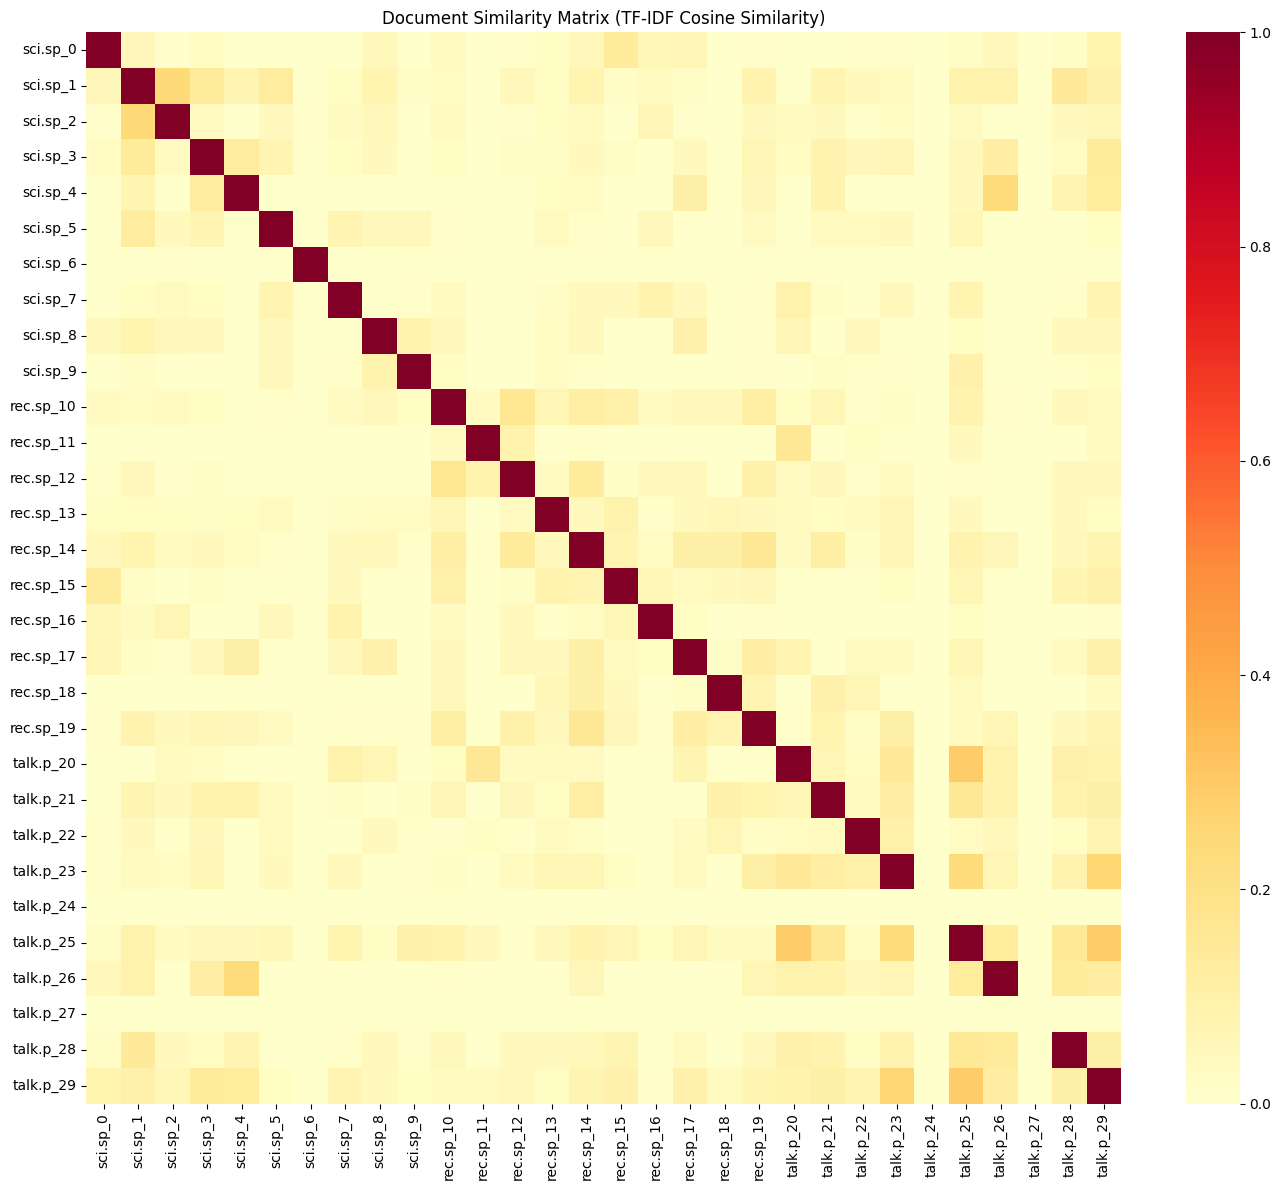

In [38]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: Yes, documents from the same category cluster together. We can clearly see 3 dark red squares along the diagonal, one for sci.space (0-9), one for rec.sport.hockey (10-19), and one for talk.politics.guns (20-29). This means documents from the same category are much more similar to each other than to documents from other categories.

2. Most/Least similar category pairs:

*   The most similar pair is rec.sport.hockey and talk.politics.guns. We can see some light orange cells between rows 10-19 and rows 20-29, which means they share some common words.
*   The least similar pair is sci.space and rec.sport.hockey. The cells between these two groups are almost all light yellow, which means very low similarity. This makes sense because space science and hockey have completely different vocabularies.

3. Surprising similarities: Yes, there are a few surprising cases. For example, sci.sp_4 shows some similarity with documents in the talk.politics.guns group (visible orange cells). Also talk.p_26 looks similar to some sci.space documents. This could be explained by the fact that some documents in these categories talk about general topics like government funding or technology, which are words that can appear in both space and politics discussions.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
